# ML — Car Price Prediction

## Objectives
* Prepare data for machine learning by encoding categorical variables and scaling features
* Test multiple regression algorithms using quick search with default hyperparameters
* Identify the best performing algorithms for extensive hyperparameter optimisation
* Optimise the best model using GridSearchCV
* Evaluate model performance using R², RMSE and MAE on both train and test sets
* Identify the most important features for predicting car price
* Save the best model for use in the Streamlit app

## Inputs
* outputs/datasets/cleaned/car_prices_cleaned.csv


## Outputs
* Trained ML model saved to outputs/models/
* Model performance metrics (RMSE, R²)
* Feature importance visualisation

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2'

# Section 1 — Load Data

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from feature_engine.encoding import OrdinalEncoder

df = pd.read_csv('outputs/datasets/cleaned/car_prices_cleaned.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand,price_per_horsepower,price_per_enginesize
0,1,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,121.576577,103.807692
1,2,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,148.648649,126.923077
2,3,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,107.142857,108.552632
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,3.40,10.0,102,5500,24,30,13950.0,audi,136.764706,127.981651
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,3.40,8.0,115,5500,18,22,17450.0,audi,151.739130,128.308824


---

# Section 2 — Data Preparation
We follow the CRISP-DM workflow and build a scikit-learn pipeline with:
* Feature Scaling — StandardScaler
* Feature Selection — SelectFromModel
* Model — tested with multiple algorithms

The target variable is **price** (continuous) — this is a **regression** task.

## CarBrand Extraction
CarBrand is extracted from CarName and cleaned before entering the pipeline.
The following typo corrections were applied to ensure brand names are 
consistent — without these corrections, misspelled names would be treated 
as separate categories by the model, leading to incorrect predictions.

* 'maxda' → 'mazda'
* 'porcshce' → 'porsche'
* 'toyouta' → 'toyota'
* 'vokswagen' / 'vw' → 'volkswagen'

In [5]:
# Extract CarBrand from CarName (moved here from ETL as per lecturer feedback)
df['CarBrand'] = df['CarName'].str.split().str[0].str.lower()
df['CarBrand'] = df['CarBrand'].replace({
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
})

In [6]:
# Drop columns not useful for ML
features = ['enginesize', 'horsepower', 'curbweight', 'carwidth', 
            'carlength', 'wheelbase', 'boreratio', 'stroke',
            'compressionratio', 'peakrpm', 'citympg', 'highwaympg',
            'fueltype', 'aspiration', 'doornumber', 'carbody', 
            'drivewheel', 'enginelocation', 'enginetype', 
            'cylindernumber', 'fuelsystem', 'CarBrand']

X = df[features]
y = df['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget variable: price")
print(f"Mean price: ${y.mean():.2f}")

Features shape: (205, 22)
Target shape: (205,)

Target variable: price
Mean price: $13276.71


In [7]:
categorical_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody', 
                    'drivewheel', 'enginelocation', 'enginetype', 
                    'fuelsystem', 'CarBrand']

numerical_cols = ['enginesize', 'horsepower', 'curbweight', 'carwidth', 
                  'carlength', 'wheelbase', 'boreratio', 'stroke',
                  'compressionratio', 'peakrpm', 'citympg', 'highwaympg',
                  'cylindernumber', 'doornumber']

In [8]:
# Ensure categorical columns are of type object
X = df[features].copy()
for col in categorical_cols:
    X[col] = X[col].astype(str)

## Train/Test Split
80% of the data is used to train the model, 20% is held back to test 
how the model performs on unseen data. random_state=0 ensures 
reproducibility — the same split every time.

In [9]:
encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=categorical_cols)

X_encoded = encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=0)

print(f"* Train set: {X_train.shape} {y_train.shape}")
print(f"* Test set: {X_test.shape} {y_test.shape}")

* Train set: (164, 22) (164,)
* Test set: (41, 22) (41,)


/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2/.venv/lib/python3.11/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2/.venv/lib/python3.11/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2/.venv/lib/python3.11/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/Users/til

---

# Section 3 — ML Pipeline

Following the scikit-learn pipeline workflow, we define 
a pipeline with three steps:
1. Feature encoding — OrdinalEncoder for categorical variables
2. Feature scaling — StandardScaler for numerical variables  
3. Feature selection — SelectFromModel
4. Model

In [10]:
def PipelineRegression(model):
    pipeline_base = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('feat_scaling', StandardScaler()),
        ('feat_selection', SelectFromModel(model)),
        ('model', model),
    ])
    return pipeline_base

---

# Section 4 — Hyperparameter Optimisation

We use the HyperparameterOptimizationSearch class to 
test multiple regression algorithms simultaneously.

Strategy (two-step search):
1. Quick search with default hyperparameters on all algorithms
2. Extensive search on the best performing algorithms

In [11]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model = PipelineRegression(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring)
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                 'estimator': key,
                 'min_score': min(scores),
                 'max_score': max(scores),
                 'mean_score': np.mean(scores),
                 'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))
            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

---

## Define Algorithms and Hyperparameters

## Step 1 — Run Quick Search with Default Hyperparameters
All algorithms are tested with default hyperparameters to identify 
which ones best fit the car price data.

In [12]:
models_search = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
}

params_search = {
    "LinearRegression": {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
}

In [13]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring='r2',
           n_jobs=-2,
           cv=5)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits



Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [14]:
score_summary, _ = search.score_summary(sort_by='mean_score')
score_summary[['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']]

,estimator,min_score,mean_score,max_score,std_score
4,ExtraTreesRegressor,0.869871,0.912933,0.958587,0.031629
3,GradientBoostingRegressor,0.867393,0.910803,0.936311,0.023822
2,RandomForestRegressor,0.843255,0.888813,0.917493,0.02542
1,DecisionTreeRegressor,0.670327,0.806097,0.853641,0.06902
0,LinearRegression,0.478375,0.763131,0.888719,0.149489


### Quick Search Results
ExtraTreesRegressor and GradientBoostingRegressor perform best with 
a mean R2 score of approximately 0.91, meaning the models explain 91% of the 
variance in car prices.

These two algorithms will be taken forward for extensive 
hyperparameter optimisation in Step 2.

---

## Step 2 — Extensive Hyperparameter Search
Based on the quick search results, we run an extensive hyperparameter 
search on the two best performing algorithms: ExtraTreesRegressor 
and GradientBoostingRegressor.

In [15]:
models_search_2 = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
}

params_search_2 = {
    "ExtraTreesRegressor": {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_leaf': [1, 2, 4],
    },
    "GradientBoostingRegressor": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5],
    }
}

search_2 = HyperparameterOptimizationSearch(
    models=models_search_2, 
    params=params_search_2)

search_2.fit(X_train, y_train,
             scoring='r2',
             n_jobs=-2,
             cv=5)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [16]:
score_summary_2, _ = search_2.score_summary(sort_by='mean_score')
score_summary_2[['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']]

,estimator,min_score,mean_score,max_score,std_score
9,ExtraTreesRegressor,0.869426,0.913872,0.957357,0.030509
10,ExtraTreesRegressor,0.866122,0.913529,0.957806,0.031668
19,ExtraTreesRegressor,0.865309,0.913522,0.960385,0.033656
1,ExtraTreesRegressor,0.865309,0.913522,0.960385,0.033656
28,GradientBoostingRegressor,0.868751,0.913056,0.937662,0.023416
2,ExtraTreesRegressor,0.864025,0.91302,0.958662,0.033118
20,ExtraTreesRegressor,0.864025,0.91302,0.958662,0.033118
18,ExtraTreesRegressor,0.869871,0.912933,0.958587,0.031629
0,ExtraTreesRegressor,0.869871,0.912933,0.958587,0.031629
11,ExtraTreesRegressor,0.864147,0.912557,0.957614,0.032187


In [17]:
best_model_key = score_summary_2.iloc[0]['estimator']
best_params = search_2.grid_searches[best_model_key].best_params_
best_estimator = search_2.grid_searches[best_model_key].best_estimator_

print(f"Best model: {best_model_key}")
print(f"Best parameters: {best_params}")

Best model: ExtraTreesRegressor
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


### Best Model
The best performing model is ExtraTreesRegressor with the following 
hyperparameters selected automatically by GridSearchCV:
* max_depth: 10
* min_samples_leaf: 1
* n_estimators: 100

In [18]:
# from LMS SciKit-Learn Topic 7 Cross Validation Search

def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)

def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print(f"  R2 Score: {r2_score(y, prediction).round(3)} \n")
    print(f"  Mean Absolute Error: {mean_absolute_error(y, prediction).round(3)} \n")
    print(f"  Mean Squared Error: {mean_squared_error(y, prediction).round(3)} \n")
    print(f"  Root Mean Squared Error: {np.sqrt(mean_squared_error(y, prediction)).round(3)} \n")

## Model Evaluation
Evaluating the best model — ExtraTreesRegressor — on both 
train and test sets using R², RMSE, MAE and scatter plots.

Model Evaluation 

* Train Set
  R2 Score: 0.998 

  Mean Absolute Error: 211.691 

  Mean Squared Error: 142949.409 

  Root Mean Squared Error: 378.087 

* Test Set
  R2 Score: 0.911 

  Mean Absolute Error: 1571.948 

  Mean Squared Error: 6856782.586 

  Root Mean Squared Error: 2618.546 



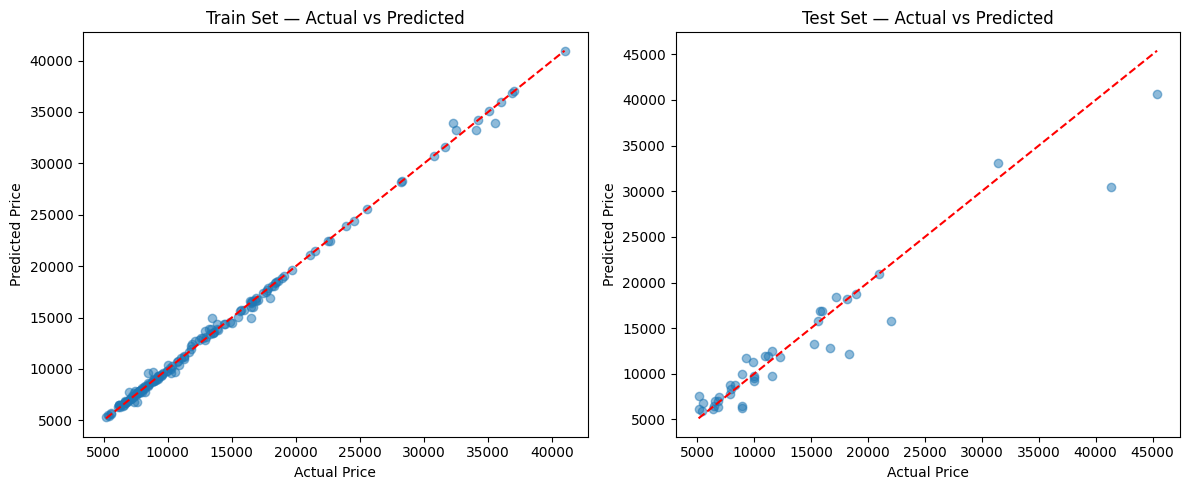

In [20]:
# from LMS SciKit-Learn Topic 4 - Cross Validation Search (GridSearchCV) and Hyperparameter Optimisation Regression 
import matplotlib.pyplot as plt

def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(y_train, pred_train, alpha=alpha_scatter)
    axes[0].plot([y_train.min(), y_train.max()], 
                 [y_train.min(), y_train.max()], 'r--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')
    axes[0].set_title('Train Set — Actual vs Predicted')

    axes[1].scatter(y_test, pred_test, alpha=alpha_scatter)
    axes[1].plot([y_test.min(), y_test.max()], 
                 [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Predicted Price')
    axes[1].set_title('Test Set — Actual vs Predicted')

    plt.tight_layout()
    plt.show()

regression_performance(X_train, y_train, X_test, y_test, best_estimator)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_estimator, alpha_scatter=0.5)

### Model Performance

**Train Set:**
* R2: 0.998 — the model explains 99.8% of variance in training data
* RMSE: $378 — average prediction error on training data

**Test Set:**
* R2: 0.911 — the model explains 91.1% of variance in unseen data
* RMSE: $2,619 — average prediction error on unseen data

**Note on overfitting:**
The gap between train R2 (0.998) and test R2 (0.911) indicates mild overfitting. 
This is partly expected given the small dataset size (205 rows). 
The test R2 of 0.911 is still considered a strong result.

---

## Feature Importance
Feature importance shows which variables have the greatest influence 
on the model's price predictions. This helps us understand which car 
attributes matter most when determining price.

In [21]:
feature_importance = best_estimator.named_steps['model'].feature_importances_
feature_names = best_estimator.named_steps['feat_selection'].get_support()

# Get selected feature names
selected_features = X_train.columns[feature_names]

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

fig = px.bar(importance_df, x='Importance', y='Feature',
             orientation='h',
             title='Feature Importance — ExtraTreesRegressor',
             labels={'Importance': 'Importance Score', 'Feature': 'Feature'})
fig.show()

### Feature Importance Results

The model selected 8 features as most important for predicting car price:

1. enginesize (~0.20) — strongest predictor, confirming Hypothesis 1
2. curbweight — consistent with EDA finding
3. cylindernumber — engine complexity influences price
4. carwidth — physical size of the car
5. horsepower — performance metric
6. citympg — fuel efficiency
7. drivewheel — drivetrain type
8. highwaympg — fuel efficiency on highways

**Key insight:** The ML model broadly confirms our EDA findings — enginesize 
remains the strongest predictor. However ExtraTreesRegressor distributes 
importance more evenly across 8 features compared to GradientBoosting's 4.

**Connection to EDA:**
These results confirm our EDA findings from Hypothesis 1:
* enginesize was the strongest correlator with price (0.87) in EDA — confirmed here
* curbweight was unexpectedly strong in EDA (0.84) — confirmed here as second most important
* horsepower was third in EDA (0.81) — confirmed here as fifth most important

---

## Save Model
The best model is saved to outputs/models/ so it can be loaded 
and used in the Streamlit app for price predictions.

In [22]:
os.makedirs('outputs/models', exist_ok=True)
joblib.dump(best_estimator, 'outputs/models/car_price_model.pkl')
print("Model saved successfully!")

joblib.dump(encoder, 'outputs/models/encoder.pkl')
print("Encoder saved successfully!")

Model saved successfully!
Encoder saved successfully!
